# Mestrado em Inteligência Artificial 25/26

# Practical 2 — Markov Decision Processes (MDPs) with Gridworld

In the theory class you saw the **MDP framework** and the **Bellman equations**.
In this practical we will implement:

1. A small **Gridworld MDP**
2. **Policy Evaluation** (Bellman *expectation* backup)
3. **Value Iteration** (Bellman *optimality* backup)
4. A **visualization** of the value function and policy

We will use a **Sutton-style** gridworld:
- Grid: **4×4**
- Terminal states: **top-left (0,0)** and **bottom-right (3,3)**
- Reward: **-1 per step** (including bumping into walls)
- Discount factor: $\gamma = 0.9$ (slightly discounted)

What's the optimal behaviour?

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

np.set_printoptions(precision=3, suppress=True)

## 1) Gridworld MDP

We define:
- **States**: cells \((row,column)\)
- **Actions**: `U, D, L, R`
- **Transition**: deterministic (attempted move; if off-grid you stay)
- **Reward**: -1 each step; terminal states end the episode

We will implement an `env.step(state, action)` that returns:
`next_state, reward, done_flag`

In [21]:
ACTIONS = ["U", "D", "L", "R"]
ACTION_TO_DELTA = {
    "U": (-1, 0),
    "D": ( 1, 0),
    "L": ( 0,-1),
    "R": ( 0, 1),
}

@dataclass(frozen=True)
class Gridworld:
    n_rows: int = 4
    n_cols: int = 4
    terminal_states: Tuple[Tuple[int,int], ...] = ((0,0), (3,3))
    step_reward: float = -1.0

    def states(self) -> List[Tuple[int,int]]:
        return [(row,column) for row in range(self.n_rows) for column in range(self.n_cols)]

    def is_terminal(self, state: Tuple[int,int]) -> bool:
        return state in self.terminal_states

    def step(self, state: Tuple[int,int], action: str) -> Tuple[Tuple[int,int], float, bool]:
        if self.is_terminal(state):
            return state, 0.0, True  # terminal state

        # TODO 1--- YOUR CODE STARTS HERE ---
        # Movimento proposto
        dr, dc = ACTION_TO_DELTA[action]
        r, c = state
        next_r, next_c = r + dr, c + dc

        # Verifica limites do grid
        if 0 <= next_r < self.n_rows and 0 <= next_c < self.n_cols:
            next_state = (next_r, next_c)
        else:
            next_state = state  # bateu na parede

        reward = self.step_reward
        done_flag = self.is_terminal(next_state)
        # --- YOUR CODE ENDS HERE ---

        return next_state, reward, done_flag

env = Gridworld()
env.states()[:5], env.terminal_states

([(0, 0), (0, 1), (0, 2), (0, 3), (1, 0)], ((0, 0), (3, 3)))

### Quick sanity checks

In [22]:
# From a non-terminal, moving into a wall keeps you in place but still costs -1
print("From (0,1) with U:", env.step((0,1), "U"))
# From a non-terminal, moving toward terminal
print("From (0,1) with L:", env.step((0,1), "L"))
# From terminal, stay terminal
print("From (0,0) with R:", env.step((0,0), "R"))

From (0,1) with U: ((0, 1), -1.0, False)
From (0,1) with L: ((0, 0), -1.0, True)
From (0,0) with R: ((0, 0), 0.0, True)


## 2) Utilities: indexing states and initializing V

We'll store $V$ (state-value function) as a 2D array `V[r,c]`.

In [23]:
def zeros_V(env: Gridworld) -> np.ndarray:
    return np.zeros((env.n_rows, env.n_cols), dtype=float)

def all_states(env: Gridworld) -> List[Tuple[int,int]]:
    return env.states()

V0 = zeros_V(env)
V0

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## 3) Policy definition

We start with a **uniform random policy**:
$\pi(a\mid s)=\frac{1}{4}$ for all non-terminal states.

In [24]:
def uniform_random_policy(env: Gridworld) -> Dict[Tuple[int,int], Dict[str, float]]:
    policy = {}
    for s in env.states():
        if env.is_terminal(s):
            policy[s] = {a: 0.0 for a in ACTIONS} #ACTIONS = ["U", "D", "L", "R"]
        else:
            policy[s] = {a: 1.0/len(ACTIONS) for a in ACTIONS}
    return policy

policy = uniform_random_policy(env)
policy[(1,1)]

{'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}

In [25]:
policy

{(0, 0): {'U': 0.0, 'D': 0.0, 'L': 0.0, 'R': 0.0},
 (0, 1): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (0, 2): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (0, 3): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (1, 0): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (1, 1): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (1, 2): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (1, 3): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (2, 0): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (2, 1): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (2, 2): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (2, 3): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (3, 0): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (3, 1): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (3, 2): {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25},
 (3, 3): {'U': 0.0, 'D': 0.0, 'L': 0.0, 'R': 0.0}}

## 4) Policy Evaluation (compute $V_{\pi}$)

Bellman expectation backup:

$
V(s) \leftarrow \sum_a \pi(a|s)\left[r(s,a) + \gamma V(s')\right]
$

### ✅ Your task
Fill in the two TODOs:
1. Compute the expected update for a single state (`bellman_expectation_update`)
2. Run iterative policy evaluation (`policy_evaluation`)

In [26]:
def bellman_expectation_update(
    env: Gridworld, V: np.ndarray, policy: Dict[Tuple[int,int], Dict[str,float]],
    state: Tuple[int,int], gamma: float
) -> float:
    """Return the updated V(s) using the Bellman expectation backup."""
    if env.is_terminal(state):
        return 0.0

    # TODO 2: compute expected value over actions under pi(a|s)
    # Hints:
    #  - loop over actions
    v_new = 0.0

    # --- YOUR CODE STARTS HERE ---
    for action, prob in policy[state].items():
        next_state, reward, done = env.step(state, action)
        if done:
            v_new += prob * reward
        else:
            v_new += prob * (reward + gamma * V[next_state[0], next_state[1]])
    # --- YOUR CODE ENDS HERE ---
    return v_new


def policy_evaluation(
    env: Gridworld,
    policy: Dict[Tuple[int,int], Dict[str,float]],
    gamma: float,
    theta: float = 1e-6,
    max_iters: int = 10_000,
) -> Tuple[np.ndarray, int]:
    """Iterative policy evaluation."""
    V = zeros_V(env)

    for it in range(max_iters):
        delta = 0.0

        # TODO 3: sweep all states and update V in-place (or into a copy)
        # Use delta = max(delta, |V_new - V_old|). Stop if delta < theta.
        # --- YOUR CODE STARTS HERE ---
        V_old = V.copy()

        for state in env.states():
            v_new = bellman_expectation_update(env, V, policy, state, gamma)
            delta = max(delta, abs(v_new - V[state[0], state[1]]))
            V[state[0], state[1]] = v_new
        # --- YOUR CODE ENDS HERE ---

        if delta < theta:
            return V, it + 1

    return V, max_iters

In [27]:
gamma = 0.9
V_pi, iters = policy_evaluation(env, policy, gamma=gamma, theta=1e-8)
print("Converged in iterations:", iters)
V_pi

Converged in iterations: 77


array([[ 0.   , -5.278, -7.128, -7.651],
       [-5.278, -6.606, -7.181, -7.128],
       [-7.128, -7.181, -6.606, -5.278],
       [-7.651, -7.128, -5.278,  0.   ]])

## 5) Value Iteration (approximate $V^{*}$)

Bellman optimality backup:

$
V(s) \leftarrow \max_a \left[r(s,a) + \gamma V(s')\right]
$

We then extract a greedy policy:
$\pi(s)=\arg\max_a\,[r(s,a)+\gamma V(s')]$

In [28]:
def bellman_optimality_update(env: Gridworld, V: np.ndarray, s: Tuple[int,int], gamma: float) -> float:
    if env.is_terminal(s):
        return 0.0
    best = -np.inf
    for a in ACTIONS:
        ns, r, done = env.step(s, a)
        best = max(best, r + gamma * V[ns[0], ns[1]])
        # max instead of summing as we were doing before: v_new += p * (r + gamma * V[ns[0], ns[1]])
    return best

def value_iteration(
    env: Gridworld,
    gamma: float,
    theta: float = 1e-6,
    max_iters: int = 10_000,
) -> Tuple[np.ndarray, int]:
    V = zeros_V(env)
    for it in range(max_iters):
        delta = 0.0
        V_old = V.copy()
        for s in env.states():
            v_new = bellman_optimality_update(env, V_old, s, gamma)
            delta = max(delta, abs(v_new - V[s[0], s[1]]))
            V[s[0], s[1]] = v_new
        if delta < theta:
            return V, it + 1
    return V, max_iters

V_star, iters_vi = value_iteration(env, gamma=gamma, theta=1e-8)
print("Converged in iterations:", iters_vi)
V_star

Converged in iterations: 4


array([[ 0.  , -1.  , -1.9 , -2.71],
       [-1.  , -1.9 , -2.71, -1.9 ],
       [-1.9 , -2.71, -1.9 , -1.  ],
       [-2.71, -1.9 , -1.  ,  0.  ]])

In [29]:
def greedy_policy_from_V(env: Gridworld, V: np.ndarray, gamma: float) -> Dict[Tuple[int,int], str]:
    pi_greedy = {}
    for s in env.states():
        if env.is_terminal(s):
            pi_greedy[s] = "·"
            continue

        # TODO 4: get the best 'a' and 'q' (q is a one-step lookahead action value)
        # Hint: q(s, a) = r(s, a) + gamma * V(s')
        # --- YOUR CODE STARTS HERE ---
        best_action = None
        best_q = -float("inf")

        for action in ACTIONS:
            next_state, reward, done = env.step(s, action)
            q = reward + gamma * V[next_state[0], next_state[1]]

            if q > best_q:
                best_q = q
                best_action = action

        pi_greedy[s] = best_action
        # --- YOUR CODE ENDS HERE ---
    return pi_greedy

pi_star = greedy_policy_from_V(env, V_star, gamma=gamma)
pi_star[(2,2)], pi_star[(0,1)], pi_star[(1,0)]

('D', 'L', 'U')

## 5.5) Compute the action-value function $Q^{\pi}$

So far, we computed **state-value functions**.
We now introduce the **action-value function**.


For a deterministic environment, the Bellman expectation equation for $Q^{\pi}$ is:

$$
Q^{\pi}(s,a) = r(s,a) + \gamma \sum_{a'} \pi(a'\mid s')\,Q^{\pi}(s',a')
$$

where $(s', r, done) = \texttt{step}(s,a)$.

We'll implement **iterative evaluation of $Q^{\pi}$** and verify:

$$
V^{\pi}(s) = \sum_a \pi(a\mid s)\,Q^{\pi}(s,a)
$$

In [30]:
def zeros_Q(env: Gridworld) -> np.ndarray:
    # Q[r,c,a_index]
    return np.zeros((env.n_rows, env.n_cols, len(ACTIONS)), dtype=float)

def policy_evaluation_Q(
    env: Gridworld,
    pi: Dict[Tuple[int,int], Dict[str,float]],
    gamma: float,
    theta: float = 1e-6,
    max_iters: int = 10_000,
) -> Tuple[np.ndarray, int]:
    Q = zeros_Q(env)

    for it in range(max_iters):
        delta = 0.0
        Q_old = Q.copy()

        for (r,c) in env.states():
            s = (r,c)
            if env.is_terminal(s):
                Q[r,c,:] = 0.0
                continue

            for ai, a in enumerate(ACTIONS):
                ns, reward, done = env.step(s, a)
                nr, nc = ns

                # Expected over next action under pi
                exp_next = 0.0
                for aj, a2 in enumerate(ACTIONS):
                    exp_next += pi[ns][a2] * Q_old[nr, nc, aj] # 0.25 * Q[nr,nc,aj]

                q_new = reward + gamma * exp_next
                delta = max(delta, abs(q_new - Q[r,c,ai]))
                Q[r,c,ai] = q_new

        if delta < theta:
            return Q, it + 1

    return Q, max_iters

# CMB - ALterado pi para policy
Q_pi, itq = policy_evaluation_Q(env, policy, gamma=gamma, theta=1e-8)
print("Q^pi converged in iterations:", itq)

Q^pi converged in iterations: 118


## 6) Visualization

We will visualize:
- The value function as numbers inside the grid
- A policy as arrows

This is the part that makes Bellman backups “click”.

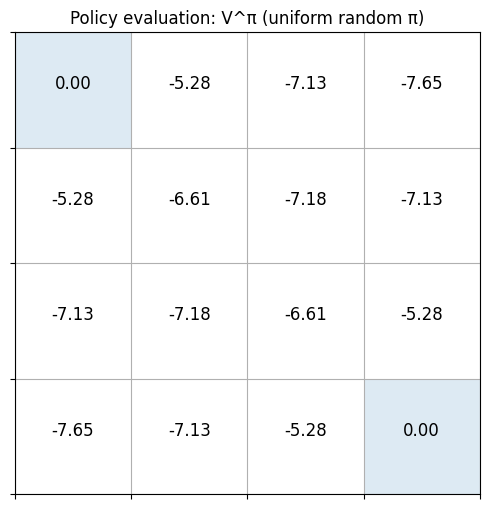

In [31]:
ARROW = {"U":"↑", "D":"↓", "L":"←", "R":"→", "·":"·"}

def plot_grid_values_and_policy(
    env: Gridworld,
    V: np.ndarray,
    policy: Optional[Dict[Tuple[int,int], str]] = None,
    title: str = "",
    value_fmt: str = "{:.2f}",
):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_title(title)

    # draw grid lines
    ax.set_xlim(0, env.n_cols)
    ax.set_ylim(0, env.n_rows)
    ax.set_xticks(np.arange(env.n_cols+1))
    ax.set_yticks(np.arange(env.n_rows+1))
    ax.grid(True)
    ax.invert_yaxis()  # row 0 at top
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # highlight terminal states
    for (r,c) in env.terminal_states:
        rect = plt.Rectangle((c, r), 1, 1, fill=True, alpha=0.15)
        ax.add_patch(rect)

    # put values + arrows
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            s = (r,c)
            v = V[r,c]
            txt = value_fmt.format(v)
            ax.text(c+0.5, r+0.45, txt, ha="center", va="center", fontsize=12)
            if policy is not None:
                a = policy[s] if s in policy else "·"
                ax.text(c+0.5, r+0.78, ARROW.get(a,"·"), ha="center", va="center", fontsize=18)

    plt.show()

plot_grid_values_and_policy(env, V_pi, None, title="Policy evaluation: V^π (uniform random π)")

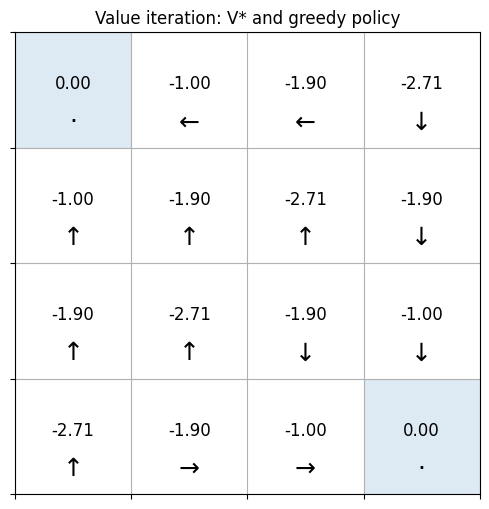

In [32]:
plot_grid_values_and_policy(env, V_star, pi_star, title="Value iteration: V* and greedy policy")

## 7) Exercises

### Exercise A — Change $\gamma$ and observe
Try `gamma = 0.5` and `gamma = 0.99`. Re-run policy evaluation and value iteration.
What changes in the value magnitude and the implied behaviour?



===== gamma = 0.5 =====
Policy Evaluation iterations: 19
Value Iteration iterations: 4
max|V_pi|=1.983  max|V*|=1.750
V_pi:
[[ 0.    -1.695 -1.949 -1.983]
 [-1.695 -1.915 -1.966 -1.949]
 [-1.949 -1.966 -1.915 -1.695]
 [-1.983 -1.949 -1.695  0.   ]]
V*:
[[ 0.   -1.   -1.5  -1.75]
 [-1.   -1.5  -1.75 -1.5 ]
 [-1.5  -1.75 -1.5  -1.  ]
 [-1.75 -1.5  -1.    0.  ]]


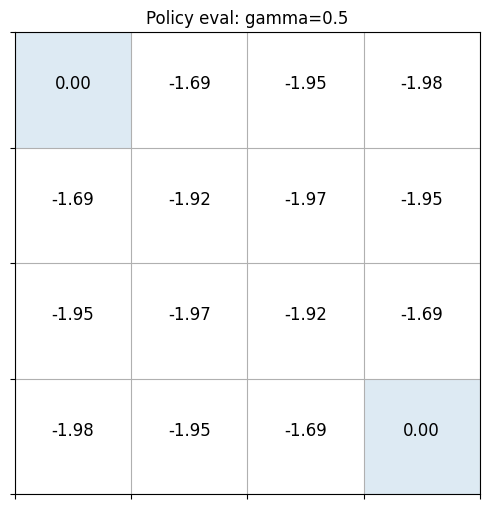

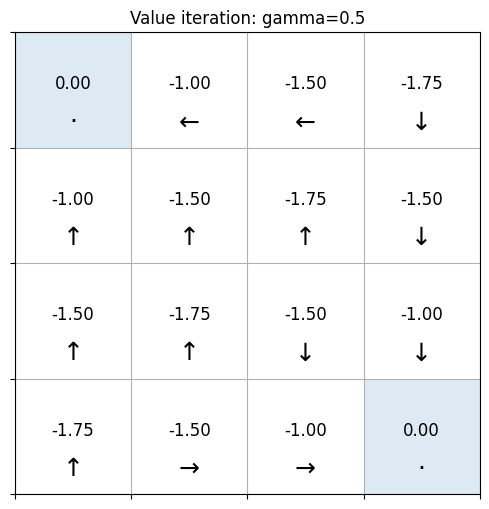


===== gamma = 0.99 =====
Policy Evaluation iterations: 186
Value Iteration iterations: 4
max|V_pi|=18.605  max|V*|=2.970
V_pi:
[[  0.    -11.945 -16.961 -18.605]
 [-11.945 -15.317 -16.978 -16.961]
 [-16.961 -16.978 -15.317 -11.945]
 [-18.605 -16.961 -11.945   0.   ]]
V*:
[[ 0.   -1.   -1.99 -2.97]
 [-1.   -1.99 -2.97 -1.99]
 [-1.99 -2.97 -1.99 -1.  ]
 [-2.97 -1.99 -1.    0.  ]]


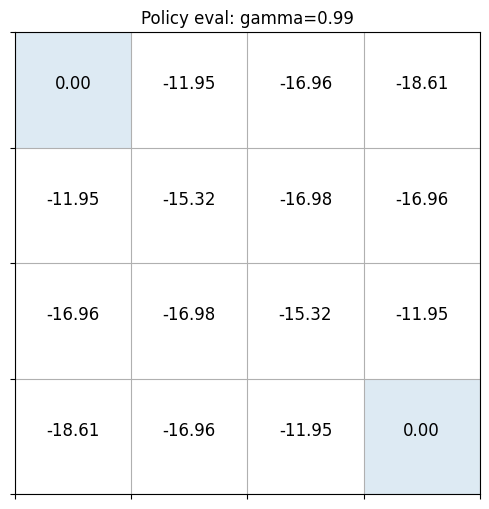

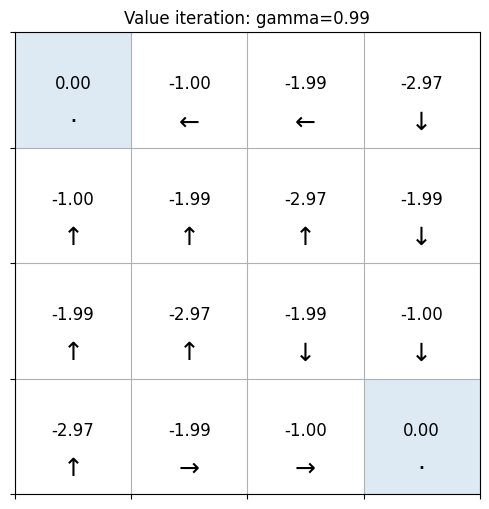

In [33]:
gammas = [0.5, 0.99]

for g in gammas:
    print(f"\n===== gamma = {g} =====")

    V_pi_g, it_pe = policy_evaluation(env, policy, gamma=g, theta=1e-8)
    V_star_g, it_vi = value_iteration(env, gamma=g, theta=1e-8)
    pi_star_g = greedy_policy_from_V(env, V_star_g, gamma=g)

    print(f"Policy Evaluation iterations: {it_pe}")
    print(f"Value Iteration iterations: {it_vi}")
    print(f"max|V_pi|={np.max(np.abs(V_pi_g)):.3f}  max|V*|={np.max(np.abs(V_star_g)):.3f}")
    print("V_pi:")
    print(np.round(V_pi_g, 3))
    print("V*:")
    print(np.round(V_star_g, 3))

    plot_grid_values_and_policy(env, V_pi_g, None, title=f"Policy eval: gamma={g}")

    plot_grid_values_and_policy(env, V_star_g, pi_star_g, title=f"Value iteration: gamma={g}")


### Exercise B — Add a “trap” cell
Pick a cell, e.g. (1,2), and make stepping *into* it give reward -10.
How does the optimal policy change? Tip: Inherit from the Gridworld class

Compare the number of iterations needed for policy iteration vs value iteration.

Policy Iteration converged in 3 policy-improvement steps
Value Iteration converged in 4 sweeps


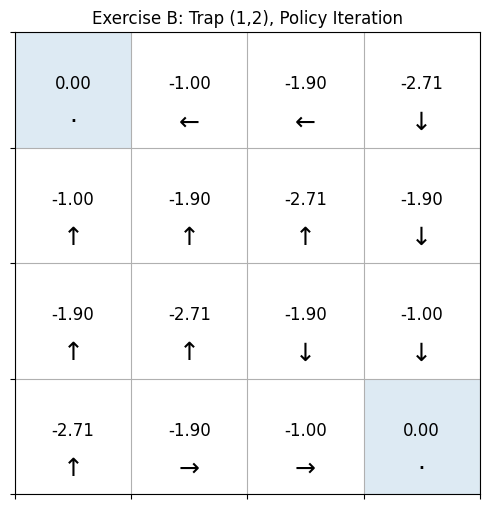

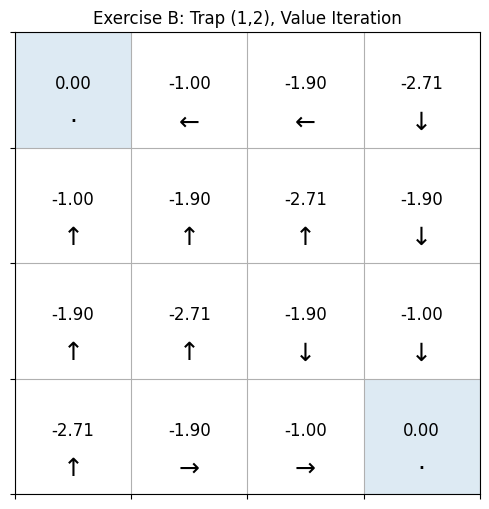

In [34]:
class TrapGridworld(Gridworld):
    def __init__(self, trap_state=(1, 2), trap_reward=-10.0, **kwargs):
        super().__init__(**kwargs)
        self.trap_state = trap_state
        self.trap_reward = trap_reward

    def step(self, state, action):
        ns, reward, done = super().step(state, action)

        # Penaliza quando ENTRA na trap (não quando já está nela)
        if (not self.is_terminal(state)) and ns == self.trap_state:
            reward = self.trap_reward

        return ns, reward, done


def policy_iteration(
    env: Gridworld,
    gamma: float,
    theta_eval: float = 1e-8,
    max_eval_iters: int = 10_000,
    max_policy_iters: int = 1_000,
):
    policy = uniform_random_policy(env)

    for it in range(max_policy_iters):
        # 1) Policy evaluation
        V, _ = policy_evaluation(
            env, policy, gamma=gamma, theta=theta_eval, max_iters=max_eval_iters
        )

        # 2) Policy improvement
        policy_stable = True
        for s in env.states():
            if env.is_terminal(s):
                continue

            old_action = max(policy[s], key=policy[s].get)

            q = {}
            for a in ACTIONS:
                ns, r, done = env.step(s, a)
                q[a] = r + gamma * (0.0 if done else V[ns[0], ns[1]])

            best_action = max(q, key=q.get)
            policy[s] = {a: (1.0 if a == best_action else 0.0) for a in ACTIONS}

            if best_action != old_action:
                policy_stable = False

        if policy_stable:
            return V, policy, it + 1

    return V, policy, max_policy_iters


def policy_probs_to_actions(env: Gridworld, policy_probs):
    pi_actions = {}
    for s in env.states():
        if env.is_terminal(s):
            pi_actions[s] = "·"
        else:
            pi_actions[s] = max(policy_probs[s], key=policy_probs[s].get)
    return pi_actions


# Run Exercise B
trap_env = TrapGridworld(trap_state=(1, 2), trap_reward=-10.0)
gamma = 0.9

# Policy Iteration
V_pi_trap, pi_prob_trap, iters_pi = policy_iteration(trap_env, gamma=gamma)
pi_trap = policy_probs_to_actions(trap_env, pi_prob_trap)

# Value Iteration
V_star_trap, iters_vi = value_iteration(trap_env, gamma=gamma, theta=1e-8)
pi_star_trap = greedy_policy_from_V(trap_env, V_star_trap, gamma=gamma)

print(f"Policy Iteration converged in {iters_pi} policy-improvement steps")
print(f"Value Iteration converged in {iters_vi} sweeps")

plot_grid_values_and_policy(
    trap_env, V_pi_trap, pi_trap,
    title="Exercise B: Trap (1,2), Policy Iteration"
)
plot_grid_values_and_policy(
    trap_env, V_star_trap, pi_star_trap,
    title="Exercise B: Trap (1,2), Value Iteration"
)


### Exercise C — Make the environment stochastic
Modify `env.step` so that with probability 0.8 the intended action happens, and with probability 0.1 you slip left/right (relative to intended direction).
What changes in $V^{*}$ and the greedy policy?


Stochastic Value Iteration converged in iterations: 25
[[ 0.    -1.332 -2.463 -3.291]
 [-1.332 -2.361 -3.134 -2.463]
 [-2.463 -3.134 -2.361 -1.332]
 [-3.291 -2.463 -1.332  0.   ]]


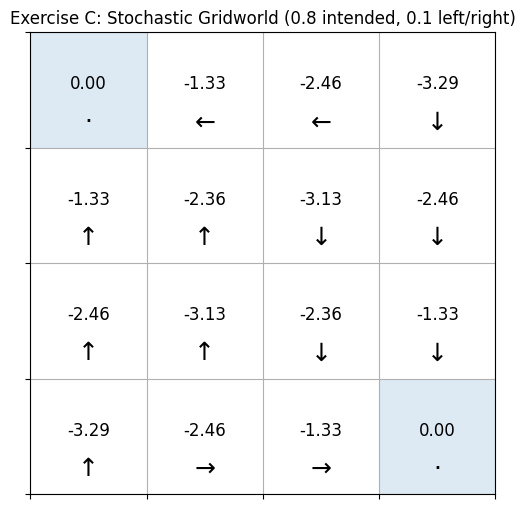

In [35]:
LEFT_OF = {"U": "L", "L": "D", "D": "R", "R": "U"}
RIGHT_OF = {"U": "R", "R": "D", "D": "L", "L": "U"}


class StochasticGridworld(Gridworld):
    def __init__(self, p_intended=0.8, p_left=0.1, p_right=0.1, **kwargs):
        super().__init__(**kwargs)
        self.p_intended = p_intended
        self.p_left = p_left
        self.p_right = p_right

    def _deterministic_move(self, state, action):
        if self.is_terminal(state):
            return state, 0.0, True

        dr, dc = ACTION_TO_DELTA[action]
        r, c = state
        nr, nc = r + dr, c + dc

        if 0 <= nr < self.n_rows and 0 <= nc < self.n_cols:
            ns = (nr, nc)
        else:
            ns = state  # wall

        reward = self.step_reward
        done = self.is_terminal(ns)
        return ns, reward, done

    # mantém step para possíveis funções que ainda usem transição única
    def step(self, state, action):
        return self._deterministic_move(state, action)

    def transition_outcomes(self, state, action):
        # devolve lista de (prob, next_state, reward, done)
        if self.is_terminal(state):
            return [(1.0, state, 0.0, True)]

        outcomes = []
        for p, a_real in [
            (self.p_intended, action),
            (self.p_left, LEFT_OF[action]),
            (self.p_right, RIGHT_OF[action]),
        ]:
            ns, r, d = self._deterministic_move(state, a_real)
            outcomes.append((p, ns, r, d))
        return outcomes


def bellman_optimality_update_stochastic(env: StochasticGridworld, V: np.ndarray, s, gamma: float) -> float:
    if env.is_terminal(s):
        return 0.0

    best = -np.inf
    for a in ACTIONS:
        q = 0.0
        for p, ns, r, done in env.transition_outcomes(s, a):
            q += p * (r + gamma * (0.0 if done else V[ns[0], ns[1]]))
        best = max(best, q)
    return best


def value_iteration_stochastic(
    env: StochasticGridworld,
    gamma: float,
    theta: float = 1e-8,
    max_iters: int = 10_000,
):
    V = zeros_V(env)

    for it in range(max_iters):
        delta = 0.0
        V_old = V.copy()

        for s in env.states():
            v_new = bellman_optimality_update_stochastic(env, V_old, s, gamma)
            delta = max(delta, abs(v_new - V[s[0], s[1]]))
            V[s[0], s[1]] = v_new

        if delta < theta:
            return V, it + 1

    return V, max_iters


def greedy_policy_from_V_stochastic(env: StochasticGridworld, V: np.ndarray, gamma: float):
    pi = {}
    for s in env.states():
        if env.is_terminal(s):
            pi[s] = "·"
            continue

        best_a, best_q = None, -np.inf
        for a in ACTIONS:
            q = 0.0
            for p, ns, r, done in env.transition_outcomes(s, a):
                q += p * (r + gamma * (0.0 if done else V[ns[0], ns[1]]))
            if q > best_q:
                best_q = q
                best_a = a
        pi[s] = best_a
    return pi


# Run Exercise C
st_env = StochasticGridworld(p_intended=0.8, p_left=0.1, p_right=0.1)
gamma = 0.9

V_star_st, it_st = value_iteration_stochastic(st_env, gamma=gamma, theta=1e-8)
pi_star_st = greedy_policy_from_V_stochastic(st_env, V_star_st, gamma=gamma)

print("Stochastic Value Iteration converged in iterations:", it_st)
print(np.round(V_star_st, 3))

plot_grid_values_and_policy(
    st_env,
    V_star_st,
    pi_star_st,
    title="Exercise C: Stochastic Gridworld (0.8 intended, 0.1 left/right)"
)
